In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path=r"C:\Users\Lenovo\Documents\DE\Week1\DAY 1\stradit-internship\week2\day1\data\HRDataset_v14.csv"

df = pd.read_csv(path)

print(df.head())


              Employee_Name  EmpID  MarriedID  MaritalStatusID  GenderID  \
0       Adinolfi, Wilson  K  10026          0                0         1   
1  Ait Sidi, Karthikeyan     10084          1                1         1   
2         Akinkuolie, Sarah  10196          1                1         0   
3              Alagbe,Trina  10088          1                1         0   
4          Anderson, Carol   10069          0                2         0   

   EmpStatusID  DeptID  PerfScoreID  FromDiversityJobFairID  Salary  ...  \
0            1       5            4                       0   62506  ...   
1            5       3            3                       0  104437  ...   
2            5       5            3                       0   64955  ...   
3            1       5            3                       0   64991  ...   
4            5       5            3                       0   50825  ...   

      ManagerName  ManagerID RecruitmentSource PerformanceScore  \
0  Michael Albert  

In [10]:
# Calculate average salary department-wise

avg_sal = df.groupby('Department')['Salary'].mean().round(2).reset_index()
print(avg_sal)

print("\n")

# Find highest-paid and lowest-paid employees

highest_paid = df.loc[df['Salary'].idxmax()]
lowest_paid = df.loc[df['Salary'].idxmin()]
print("Highest Paid Employee:")
print(highest_paid)
print("\nLowest Paid Employee:")
print(lowest_paid)






             Department     Salary
0         Admin Offices   71791.89
1      Executive Office  250000.00
2                 IT/IS   97064.64
3     Production          59953.55
4                 Sales   69061.26
5  Software Engineering   94989.45


Highest Paid Employee:
Employee_Name                        King, Janet
EmpID                                      10089
MarriedID                                      1
MaritalStatusID                                1
GenderID                                       0
EmpStatusID                                    1
DeptID                                         2
PerfScoreID                                    3
FromDiversityJobFairID                         0
Salary                                    250000
Termd                                          0
PositionID                                    16
Position                         President & CEO
State                                         MA
Zip                                         

In [ ]:
# Analyze relationship between experience and salary

df['DateofHire'] = pd.to_datetime(df['DateofHire'], errors='coerce')
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')
analysis_end_date = max(df['DateofHire'].max(), df['DateofTermination'].max())
df['Experience'] = (analysis_end_date - df['DateofHire']).dt.days / 365.25

exp_sal_corr = df['Experience'].corr(df['Salary'])
print(f"\nCorrelation between Experience and Salary: {exp_sal_corr:.2f}")


# Identify salary outliers

Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)    
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]
print(f"\nSalary Outliers:\n{outliers[['EmpID', 'Salary']]}")



Correlation between Experience and Salary: 0.06

Salary Outliers:
     EmpID  Salary
1    10084  104437
18   10245  110000
25   10199  103613
26   10081  106367
39   10082  100031
42   10108  110929
55   10019  170500
66   10155  101199
76   10028  138888
86   10290   99280
96   10015  178000
97   10080   99351
108  10246  114800
120  10234   99020
130  10112   97999
131  10272  180000
144  10156  105700
150  10089  250000
180  10110  105688
190  10288  157000
212  10005  108987
239  10149  120000
240  10086  150290
243  10198  140920
244  10222  148999
285  10102  100416
292  10118  113999
299  10127  107226
308  10010  220450


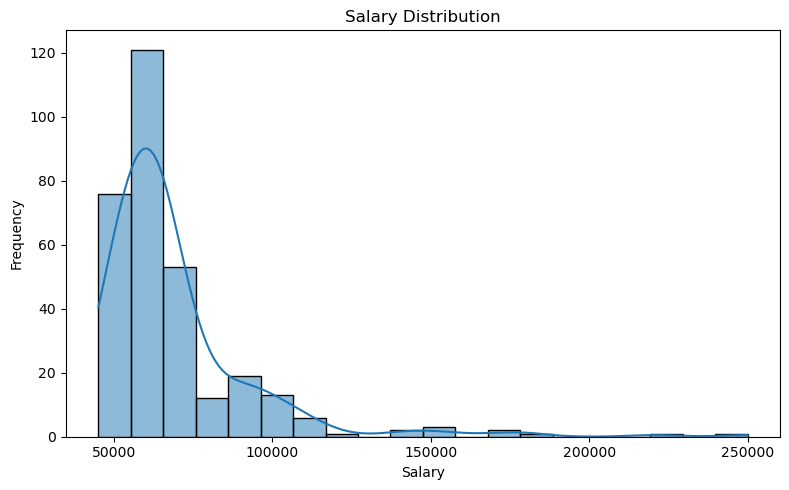

In [18]:
# Create:
# salary distribution histogram

plt.figure(figsize=(8, 5))
sns.histplot(df['Salary'], bins=20, kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


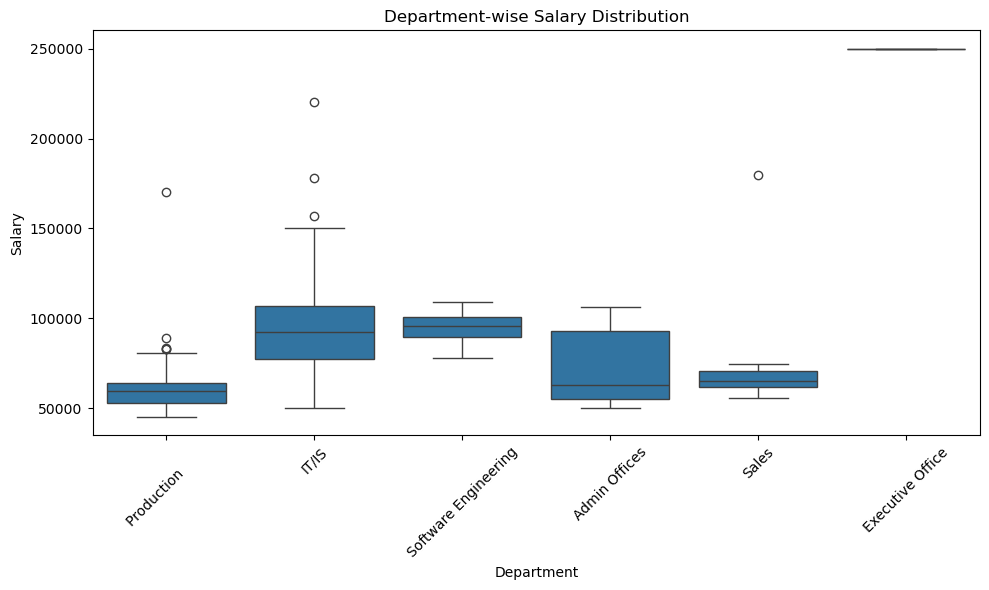

In [19]:
# department-wise boxplot

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Department', y='Salary')

plt.title('Department-wise Salary Distribution')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
# experience vs salary scatter plot

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Experience', y='Salary')
plt.title('Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

# Suggest HR improvements based on analysis

print("HR Recommendations:")

print("1. Salary of employees with lower avg should be increased.")
print("2. Compensation package should be within dataset range.")

ValueError: Could not interpret value `Experience` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>